# Assignment 3: GNN for 2D IceCube neutrino interaction

In this notebook, I implement a Dynamic Edge Convolution Graph Neural Network (GNN) to reconstruct the 2D position of the neutrino interaction from measured Cherenkov light.

The dataset is a simplified 2D IceCube-like dataset stored in three Parquet files:
- `train.pq`
- `val.pq`
- `test.pq`

Each event consists of a variable-length list of detected photons (hits).  
Each photon is described by three features:
- `t`: detection time in ns
- `x`: x-position of the detector unit in m
- `y`: y-position of the detector unit in m

The target labels are:
- `xpos`
- `ypos`

Because each event contains a variable number of hits, I represent each event as a graph where the hits are nodes. I use PyTorch Geometric and its `DynamicEdgeConv` layer, which dynamically builds a k-nearest-neighbor graph in feature space at each layer.

For each edge-convolution layer, neighboring node pairs are combined into feature vectors of twice the node-feature dimension, and processed by an MLP. In this notebook, I use:
- hidden dimension: `64`
- graph convolution output dimensions: `[64, 64]`
- number of nearest neighbors: `k = 8`

The node features are aggregated with global mean pooling to obtain one graph-level representation per event, which is then mapped to the final prediction of `(xpos, ypos)`.

To evaluate the model, I calculate regression metrics such as:
- MSE loss
- RMSE
- MAE
- \(R^2\)

and visualize the results with:
- training and validation loss curves
- predicted vs true scatter plots for `xpos` and `ypos`
- histograms of prediction errors

In [47]:
import os
import time
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import DynamicEdgeConv, global_mean_pool

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [48]:
# Hyperparameters

BATCH_SIZE = 128
NUM_EPOCHS = 30
LR = 1e-3
K = 8
HIDDEN_DIM = 64
GRAPH_DIMS = [64, 64]

USE_SMALL_SUBSET = False   # for testing
TRAIN_SUBSET = 5000
VAL_SUBSET = 1000
TEST_SUBSET = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [49]:
# Load and inspect data

train_dataset = ak.from_parquet(os.path.join(DATA_PATH, "train.pq"))
val_dataset = ak.from_parquet(os.path.join(DATA_PATH, "val.pq"))
test_dataset = ak.from_parquet(os.path.join(DATA_PATH, "test.pq"))

print(f"Train events: {len(train_dataset)}")
print(f"Val events:   {len(val_dataset)}")
print(f"Test events:  {len(test_dataset)}")
print("Fields:", train_dataset.fields)

print("\nFirst event:")
print(train_dataset[0])

print("\nFirst event labels:")
print("xpos =", train_dataset["xpos"][0], "ypos =", train_dataset["ypos"][0])

print("\nFirst event hit array shape-like info:")
print("Number of hits:", len(train_dataset["data"][0][0]))
print("Times:", train_dataset["data"][0, 0][:10])
print("X positions:", train_dataset["data"][0, 1][:10])
print("Y positions:", train_dataset["data"][0, 2][:10])

Train events: 10001
Val events:   10001
Test events:  10001
Fields: ['xpos', 'ypos', 'data', 'energy', 'xdir', 'ydir']

First event:
{xpos: 3.94, ypos: -7.12, data: [[14.5, ...], ...], energy: 10, xdir: 1, ...}

First event labels:
xpos = 3.9371957858673263 ypos = -7.117557573556748

First event hit array shape-like info:
Number of hits: 12
Times: [14.5, 17.1, 9, 12, 12.9, 25.2, 15.3, 15.1, 16.6, 19.5]
X positions: [-2.5, -2.5, 2.5, 2.5, 2.5, -2.5, 0.833, 2.5, -0.833, -0.833]
Y positions: [-2.5, -2.5, -2.5, -2.5, -2.5, -0.833, -0.833, -0.833, 0.833, 0.833]


In [50]:
# Functions for normalizing and denormalizing data

def get_feature_stats(dataset):
    times = ak.flatten(dataset["data"][:, 0, :], axis=None)
    xs = ak.flatten(dataset["data"][:, 1, :], axis=None)
    ys = ak.flatten(dataset["data"][:, 2, :], axis=None)

    xpos = dataset["xpos"]
    ypos = dataset["ypos"]

    stats = {
        "time_mean": float(ak.mean(times)),
        "time_std": float(ak.std(times)),
        "x_mean": float(ak.mean(xs)),
        "x_std": float(ak.std(xs)),
        "y_mean": float(ak.mean(ys)),
        "y_std": float(ak.std(ys)),
        "xpos_mean": float(ak.mean(xpos)),
        "xpos_std": float(ak.std(xpos)),
        "ypos_mean": float(ak.mean(ypos)),
        "ypos_std": float(ak.std(ypos)),
    }
    return stats


def normalize_dataset(dataset, stats):
    times = dataset["data"][:, 0:1, :]
    xs = dataset["data"][:, 1:2, :]
    ys = dataset["data"][:, 2:3, :]

    norm_times = (times - stats["time_mean"]) / stats["time_std"]
    norm_xs = (xs - stats["x_mean"]) / stats["x_std"]
    norm_ys = (ys - stats["y_mean"]) / stats["y_std"]

    norm_data = ak.concatenate([norm_times, norm_xs, norm_ys], axis=1)

    out = ak.Array({
        "data": norm_data,
        "xpos": (dataset["xpos"] - stats["xpos_mean"]) / stats["xpos_std"],
        "ypos": (dataset["ypos"] - stats["ypos_mean"]) / stats["ypos_std"],
    })
    return out


def denormalize_labels(arr, mean, std):
    return arr * std + mean

In [51]:
stats = get_feature_stats(train_dataset)

train_dataset = normalize_dataset(train_dataset, stats)
val_dataset = normalize_dataset(val_dataset, stats)
test_dataset = normalize_dataset(test_dataset, stats)

print(stats)

{'time_mean': 12.49209413998843, 'time_std': 5.789383960785748, 'x_mean': 0.10375347520725568, 'x_std': 1.8471392316808408, 'y_mean': 0.0027357568871528297, 'y_std': 1.8521536514550252, 'xpos_mean': -0.03322223536951355, 'xpos_std': 5.014004908653021, 'ypos_mean': 0.004824839383344266, 'ypos_std': 4.956111461250346}


In [52]:
if USE_SMALL_SUBSET:
    train_dataset = train_dataset[:TRAIN_SUBSET]
    val_dataset = val_dataset[:VAL_SUBSET]
    test_dataset = test_dataset[:TEST_SUBSET]

print(len(train_dataset), len(val_dataset), len(test_dataset))

10001 10001 10001


In [53]:
def collate_fn_gnn(batch):
    data_list = []
    labels = []

    for b in batch:

        tensordata = torch.from_numpy(b["data"].to_numpy()).T.to(torch.float32)  

        this_graph_item = Data(x=tensordata)
        data_list.append(this_graph_item)

        labels.append(torch.tensor([b["xpos"], b["ypos"]], dtype=torch.float32).unsqueeze(0))

    labels = torch.cat(labels, dim=0)
    packed_data = Batch.from_data_list(data_list)
    return packed_data, labels

In [54]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn_gnn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_gnn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn_gnn)

In [55]:
# MLP

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)

# GNN Encoder

class GNNEncoder(nn.Module):
    def __init__(
        self,
        input_dim=3,          # features: (time, x, y)
        hidden_dim=64,
        conv_dims=[64, 64],   # two DynamicEdgeConv layers
        k=8,                  # number of nearest neighbors
        output_dim=2          # predict (xpos, ypos)
    ):
        super(GNNEncoder, self).__init__()

        self.layer_list = nn.ModuleList()

        current_dim = input_dim
        for conv_dim in conv_dims:
            layer = DynamicEdgeConv(
                MLP(2 * current_dim, hidden_dim, conv_dim),
                aggr='mean',
                k=k,
            )
            self.layer_list.append(layer)
            current_dim = conv_dim

        self.final_mlp = nn.Sequential(
            nn.Linear(current_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, data):
        # data is a batch graph item. it contains a list of tensors (x) and how the batch is structured along this list (batch)
        x = data.x
        batch = data.batch

        # loop over the DynamicEdgeConv layers:
        for layer in self.layer_list:
            x = layer(x, batch)

        # the output of the last layer has one feature vector per node
        # combine node features into one graph-level feature vector
        x = global_mean_pool(x, batch)  # -> (n_batch, current_dim)

        # map pooled graph features to the label space
        x = self.final_mlp(x)

        return x

In [56]:
model = GNNEncoder(
    input_dim=3,
    hidden_dim=HIDDEN_DIM,
    conv_dims=GRAPH_DIMS,
    k=K,
    output_dim=2
).to(device)

print(model)

print("Model device:", next(model.parameters()).device)
batch_data, batch_labels = next(iter(train_loader))
batch_data = batch_data.to(device)
batch_labels = batch_labels.to(device)
print("Data device:", batch_data.x.device)
print("Labels device:", batch_labels.device)

GNNEncoder(
  (layer_list): ModuleList(
    (0): DynamicEdgeConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=6, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
      )
    ), k=8)
    (1): DynamicEdgeConv(nn=MLP(
      (net): Sequential(
        (0): Linear(in_features=128, out_features=64, bias=True)
        (1): ReLU()
        (2): Linear(in_features=64, out_features=64, bias=True)
        (3): ReLU()
      )
    ), k=8)
  )
  (final_mlp): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)
Model device: cuda:0
Data device: cuda:0
Labels device: cuda:0


In [57]:
batch_data, batch_labels = next(iter(train_loader))
batch_data = batch_data.to(device)
batch_labels = batch_labels.to(device)

with torch.no_grad():
    preds = model(batch_data)

print("Node feature tensor shape:", batch_data.x.shape)
print("Batch vector shape:", batch_data.batch.shape)
print("Label shape:", batch_labels.shape)
print("Prediction shape:", preds.shape)

Node feature tensor shape: torch.Size([2730, 3])
Batch vector shape: torch.Size([2730])
Label shape: torch.Size([128, 2])
Prediction shape: torch.Size([128, 2])


In [58]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [59]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for data, labels in loader:
        data = data.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        preds = model(data)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    preds_all = []
    labels_all = []

    for data, labels in loader:
        data = data.to(device)
        labels = labels.to(device)

        preds = model(data)
        loss = criterion(preds, labels)

        running_loss += loss.item() * labels.size(0)
        preds_all.append(preds.cpu())
        labels_all.append(labels.cpu())

    preds_all = torch.cat(preds_all, dim=0).numpy()
    labels_all = torch.cat(labels_all, dim=0).numpy()

    return running_loss / len(loader.dataset), preds_all, labels_all

In [60]:
train_losses = []
val_losses = []

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | train: {train_loss:.4f} | val: {val_loss:.4f} | time: {time.time()-t0:.1f}s")

Epoch 1/30 | train: 0.6654 | val: 0.2731 | time: 8.2s
Epoch 2/30 | train: 0.2219 | val: 0.1850 | time: 7.3s
Epoch 3/30 | train: 0.1653 | val: 0.1570 | time: 9.3s
Epoch 4/30 | train: 0.1512 | val: 0.1429 | time: 9.8s
Epoch 5/30 | train: 0.1376 | val: 0.1400 | time: 9.3s
Epoch 6/30 | train: 0.1308 | val: 0.1356 | time: 9.7s
Epoch 7/30 | train: 0.1263 | val: 0.1376 | time: 9.3s
Epoch 8/30 | train: 0.1203 | val: 0.1214 | time: 9.0s
Epoch 9/30 | train: 0.1139 | val: 0.1223 | time: 9.9s
Epoch 10/30 | train: 0.1099 | val: 0.1149 | time: 9.3s
Epoch 11/30 | train: 0.1059 | val: 0.1133 | time: 8.7s
Epoch 12/30 | train: 0.1047 | val: 0.1103 | time: 10.0s
Epoch 13/30 | train: 0.1031 | val: 0.1162 | time: 8.1s
Epoch 14/30 | train: 0.1011 | val: 0.1118 | time: 9.8s
Epoch 15/30 | train: 0.0986 | val: 0.1051 | time: 10.1s
Epoch 16/30 | train: 0.0971 | val: 0.1193 | time: 10.2s
Epoch 17/30 | train: 0.0941 | val: 0.1026 | time: 10.2s
Epoch 18/30 | train: 0.0927 | val: 0.1066 | time: 8.9s
Epoch 19/30 | t

In [61]:
test_loss, preds_norm, labels_norm = evaluate(model, test_loader, criterion, device)

pred_x = denormalize_labels(preds_norm[:, 0], stats["xpos_mean"], stats["xpos_std"])
pred_y = denormalize_labels(preds_norm[:, 1], stats["ypos_mean"], stats["ypos_std"])

true_x = denormalize_labels(labels_norm[:, 0], stats["xpos_mean"], stats["xpos_std"])
true_y = denormalize_labels(labels_norm[:, 1], stats["ypos_mean"], stats["ypos_std"])

rmse_x = np.sqrt(mean_squared_error(true_x, pred_x))
rmse_y = np.sqrt(mean_squared_error(true_y, pred_y))
mae_x = mean_absolute_error(true_x, pred_x)
mae_y = mean_absolute_error(true_y, pred_y)
r2_x = r2_score(true_x, pred_x)
r2_y = r2_score(true_y, pred_y)

print("Test loss:", test_loss)
print(f"xpos: RMSE={rmse_x:.3f}, MAE={mae_x:.3f}, R2={r2_x:.3f}")
print(f"ypos: RMSE={rmse_y:.3f}, MAE={mae_y:.3f}, R2={r2_y:.3f}")

Test loss: 0.09107784969057396
xpos: RMSE=1.284, MAE=0.866, R2=0.934
ypos: RMSE=1.692, MAE=1.112, R2=0.884


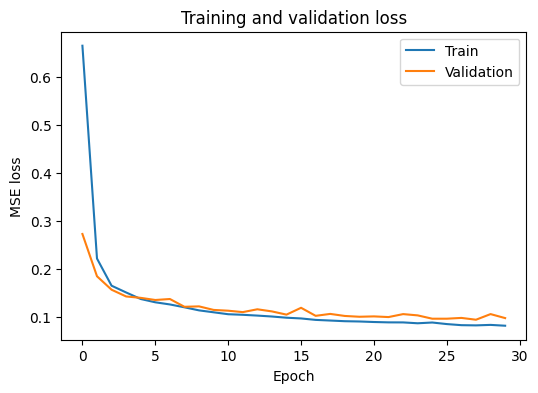

In [62]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.title("Training and validation loss")
plt.show()

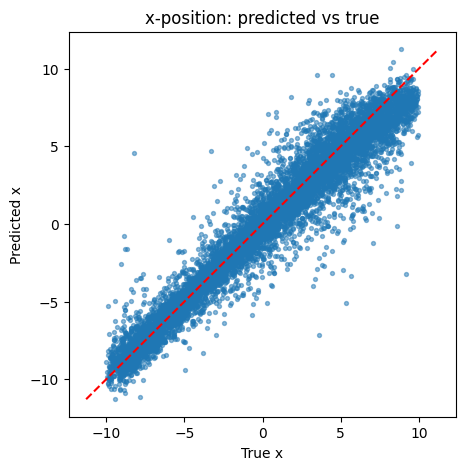

In [63]:
plt.figure(figsize=(5,5))
plt.scatter(true_x, pred_x, s=8, alpha=0.5)
mn = min(true_x.min(), pred_x.min())
mx = max(true_x.max(), pred_x.max())
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("True x")
plt.ylabel("Predicted x")
plt.title("x-position: predicted vs true")
plt.show()

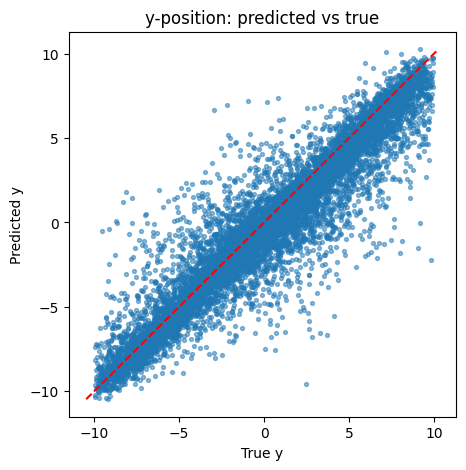

In [64]:
plt.figure(figsize=(5,5))
plt.scatter(true_y, pred_y, s=8, alpha=0.5)
mn = min(true_y.min(), pred_y.min())
mx = max(true_y.max(), pred_y.max())
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("y-position: predicted vs true")
plt.show()

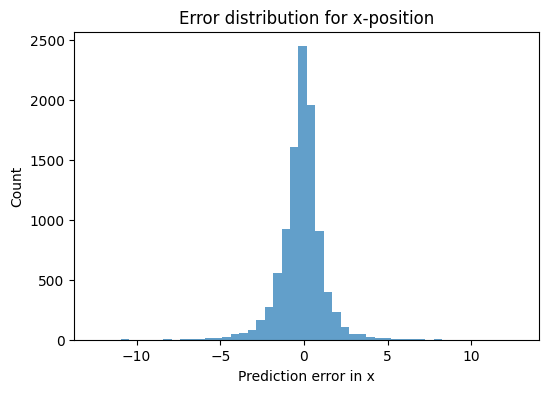

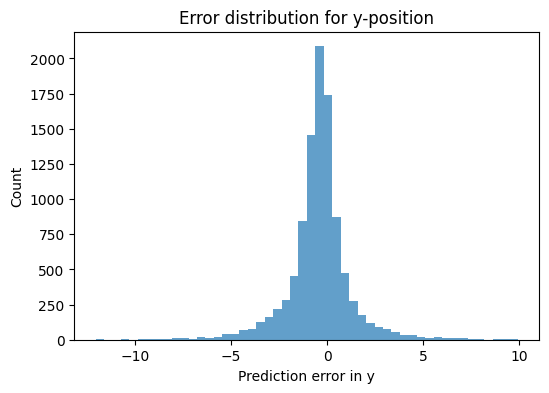

In [65]:
err_x = pred_x - true_x
err_y = pred_y - true_y

plt.figure(figsize=(6,4))
plt.hist(err_x, bins=50, alpha=0.7)
plt.xlabel("Prediction error in x")
plt.ylabel("Count")
plt.title("Error distribution for x-position")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(err_y, bins=50, alpha=0.7)
plt.xlabel("Prediction error in y")
plt.ylabel("Count")
plt.title("Error distribution for y-position")
plt.show()

Mean distance error: 1.564
Median distance error: 1.123


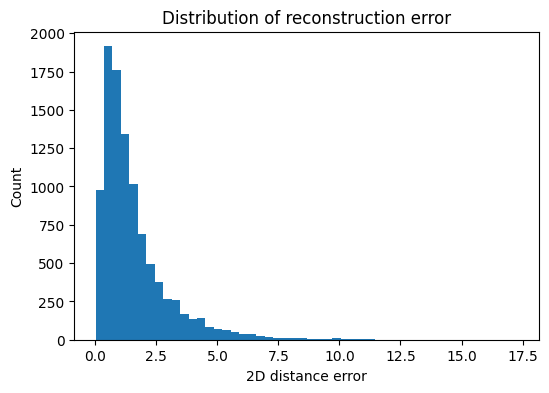

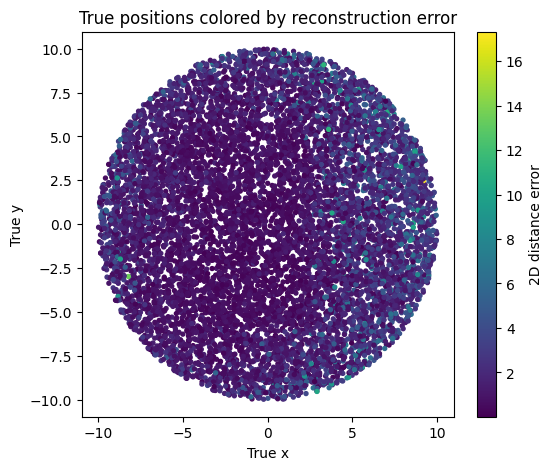

In [66]:
dist_err = np.sqrt((pred_x - true_x)**2 + (pred_y - true_y)**2)

print(f"Mean distance error: {dist_err.mean():.3f}")
print(f"Median distance error: {np.median(dist_err):.3f}")

plt.figure(figsize=(6,4))
plt.hist(dist_err, bins=50)
plt.xlabel("2D distance error")
plt.ylabel("Count")
plt.title("Distribution of reconstruction error")
plt.show()

plt.figure(figsize=(6,5))
sc = plt.scatter(true_x, true_y, c=dist_err, s=8)
plt.xlabel("True x")
plt.ylabel("True y")
plt.title("True positions colored by reconstruction error")
plt.colorbar(sc, label="2D distance error")
plt.show()